<a href="https://colab.research.google.com/github/AtulMore2327/Intro-to-Machine-Learning/blob/main/Face_Mask_Detection_CNN_(Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile
dataset = '/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Computer vision/archive.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')

In [ ]:
with_mask_files[:5]

['with_mask_879.jpg',
 'with_mask_3345.jpg',
 'with_mask_1004.jpg',
 'with_mask_1230.jpg',
 'with_mask_1399.jpg']

In [ ]:
without_mask_files[:5]

['without_mask_2675.jpg',
 'without_mask_212.jpg',
 'without_mask_1487.jpg',
 'without_mask_392.jpg',
 'without_mask_3762.jpg']

In [ ]:
len(without_mask_files)

3828

In [ ]:
len(with_mask_files)

3725

**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [ ]:
with_mask_labels = [1]*3725
without_mask_labels = [0]* 3828

In [ ]:
with_mask_labels[:5]

[1, 1, 1, 1, 1]

In [ ]:
without_mask_labels[:5]

[0, 0, 0, 0, 0]

In [ ]:
labels = with_mask_labels+without_mask_labels

In [ ]:
labels[:5]

[1, 1, 1, 1, 1]

In [ ]:
labels[-5:]

[0, 0, 0, 0, 0]

**Displaying the Images**

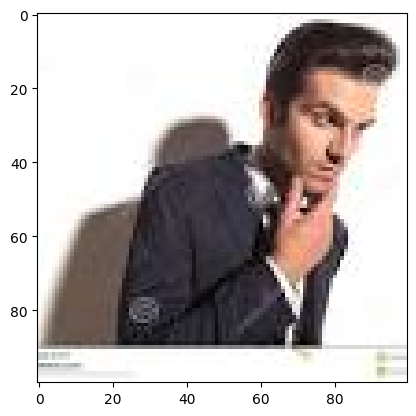

In [ ]:
img = mpimg.imread('/content/data/without_mask/without_mask_1063.jpg')
imgplot = plt.imshow(img)
plt.show()

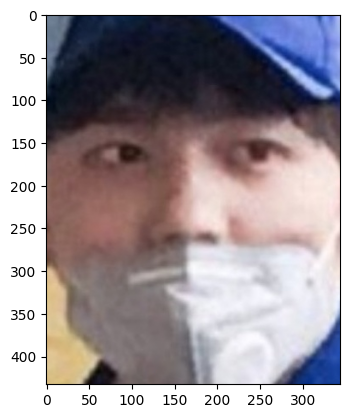

In [ ]:
img = mpimg.imread('/content/data/with_mask/with_mask_1078.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [ ]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [172, 170, 171],
        [250, 248, 249],
        [253, 251, 252]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 74,  72,  73],
        [245, 243, 244],
        [253, 252, 253]],

       [[254, 254, 254],
        [254, 254, 254],
        [253, 253, 253],
        ...,
        [231, 229, 230],
        [251, 249, 250],
        [254, 252, 253]],

       ...,

       [[214, 205, 203],
        [206, 195, 195],
        [226, 214, 215],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[206, 195, 194],
        [208, 198, 197],
        [241, 233, 233],
        ...,
        [251, 251, 251],
        [253, 253, 253],
        [253, 253, 253]],

       [[218, 207, 205],
        [238, 232, 230],
        [252, 251, 248],
        ...,
        [241, 241, 241],
        [253, 253, 253],
        [253, 253, 253]]], dtype=uint8)
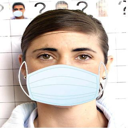

In [ ]:
data[0]

array([[[198, 152, 126],
        [201, 155, 129],
        [201, 154, 128],
        ...,
        [155, 119,  77],
        [160, 122,  81],
        [163, 122,  82]],

       [[204, 158, 132],
        [207, 160, 135],
        [208, 159, 134],
        ...,
        [157, 120,  79],
        [161, 123,  80],
        [166, 124,  83]],

       [[209, 163, 135],
        [213, 166, 138],
        [213, 164, 137],
        ...,
        [160, 122,  79],
        [166, 126,  82],
        [170, 127,  86]],

       ...,

       [[ 89,  53,  38],
        [102,  62,  45],
        [121,  75,  54],
        ...,
        [236, 194, 183],
        [253, 213, 200],
        [255, 226, 221]],

       [[ 76,  44,  32],
        [ 87,  52,  35],
        [104,  63,  43],
        ...,
        [230, 169, 152],
        [248, 182, 162],
        [254, 197, 182]],

       [[ 73,  42,  29],
        [ 81,  48,  31],
        [ 91,  54,  33],
        ...,
        [232, 156, 138],
        [249, 164, 143],
        [250, 174, 154]]], dtype=uint8)
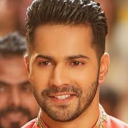

In [ ]:
data[7000]

In [ ]:
x = np.array(data)
y = np.array(labels)

**Train Test Split**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=2)

array([[[254, 254, 254],
        [253, 253, 253],
        [239, 239, 240],
        ...,
        [217, 217, 217],
        [218, 218, 218],
        [217, 217, 217]],

       [[252, 252, 252],
        [253, 253, 253],
        [195, 195, 196],
        ...,
        [ 42,  42,  42],
        [ 41,  41,  41],
        [ 44,  44,  44]],

       [[253, 253, 253],
        [252, 252, 252],
        [198, 198, 200],
        ...,
        [ 33,  33,  33],
        [ 36,  36,  36],
        [ 42,  42,  42]],

       ...,

       [[251, 255, 247],
        [254, 251, 245],
        [250, 250, 154],
        ...,
        [202, 141,  47],
        [141,  54,   7],
        [172,  84,  30]],

       [[252, 255, 247],
        [255, 253, 247],
        [250, 253, 160],
        ...,
        [239, 206,  83],
        [163,  95,  18],
        [130,  43,  15]],

       [[252, 254, 247],
        [255, 253, 246],
        [251, 254, 162],
        ...,
        [253, 242, 107],
        [198, 144,  42],
        [135,  55,  28]]], dtype=uint8)
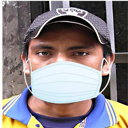

In [ ]:
x_train[0]

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
x_train[0]

array([[[0.99607843, 0.99607843, 0.99607843],
        [0.99215686, 0.99215686, 0.99215686],
        [0.9372549 , 0.9372549 , 0.94117647],
        ...,
        [0.85098039, 0.85098039, 0.85098039],
        [0.85490196, 0.85490196, 0.85490196],
        [0.85098039, 0.85098039, 0.85098039]],

       [[0.98823529, 0.98823529, 0.98823529],
        [0.99215686, 0.99215686, 0.99215686],
        [0.76470588, 0.76470588, 0.76862745],
        ...,
        [0.16470588, 0.16470588, 0.16470588],
        [0.16078431, 0.16078431, 0.16078431],
        [0.17254902, 0.17254902, 0.17254902]],

       [[0.99215686, 0.99215686, 0.99215686],
        [0.98823529, 0.98823529, 0.98823529],
        [0.77647059, 0.77647059, 0.78431373],
        ...,
        [0.12941176, 0.12941176, 0.12941176],
        [0.14117647, 0.14117647, 0.14117647],
        [0.16470588, 0.16470588, 0.16470588]],

       ...,

       [[0.98431373, 1.        , 0.96862745],
        [0.99607843, 0.98431373, 0.96078431],
        [0.98039216, 0

**Building a Convolutional Neural Networks (CNN)**

In [ ]:
import tensorflow as tf
from tensorflow import keras

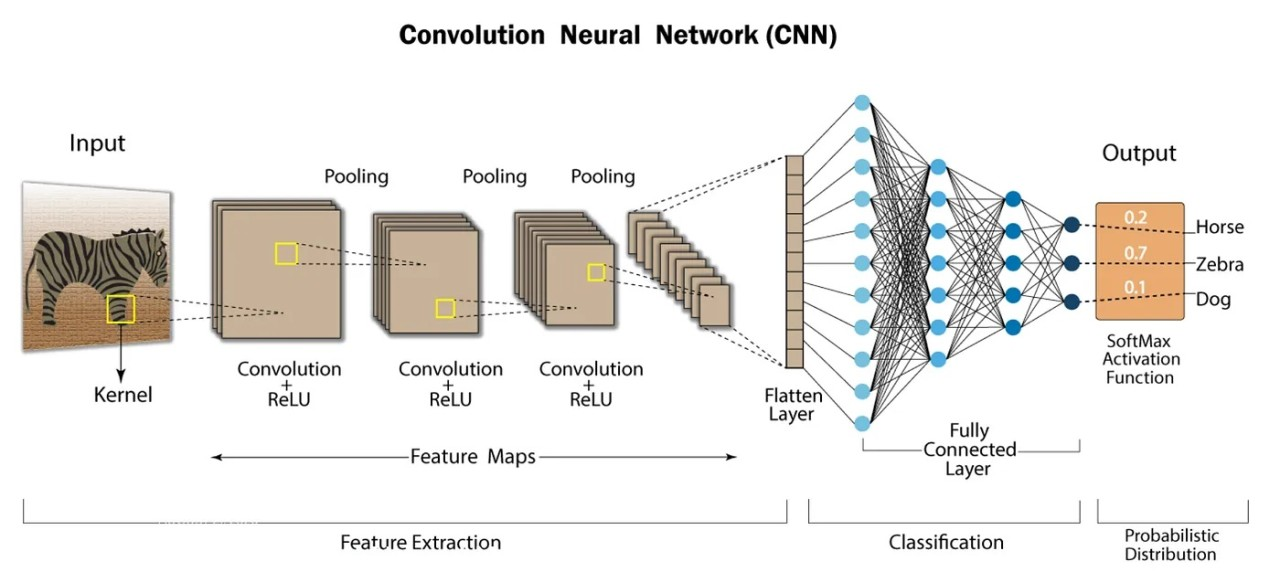

In [ ]:
num_of_classes = 2

model = keras.Sequential()

# kernel_size=(3, 3): Size of the convolution kernel.
# input_shape=(height, width, channels)
# MaxPooling2D - this layer is added after a convolutional layer to reduce the spatial dimensions of the feature maps
# -and control overfitting by reducing the number of parameters.
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
# It's a common practice to use dropout after fully connected (dense) layers
# or sometimes after convolutional layers to improve generalization.
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - acc: 0.7837 - loss: 0.4844 - val_acc: 0.8959 - val_loss: 0.2821
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8873 - loss: 0.2979 - val_acc: 0.9058 - val_loss: 0.2530
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9042 - loss: 0.2408 - val_acc: 0.9107 - val_loss: 0.2339
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9222 - loss: 0.2054 - val_acc: 0.9190 - val_loss: 0.2289
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9336 - loss: 0.1825 - val_acc: 0.8959 - val_loss: 0.2867


Path of the image to be predicted: /content/data/with_mask/with_mask_1013.jpg


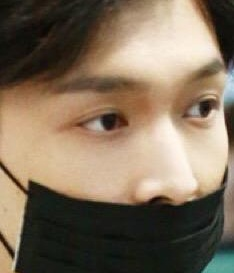

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
[[0.20924987 0.6354133 ]]
1
The person in the image is wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')